<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/week09_%ED%95%A9%EC%84%B1%EA%B3%B1%EC%8B%A0%EA%B2%BD%EB%A7%9D2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.2 합성곱 신경망 맛보기

fashion_mnist 데이터셋

o : T-Shirt   
1 : Trouser   
2 : Pullover   
3 : Dress   
4 : Coat   
5 : Sandal   
6 : Shirt   
7 : Sneaker   
8 : Bag   
9 : Ankle Boot   

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset,DataLoader

In [4]:
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [5]:
train_dataset=torchvision.datasets.FashionMNIST(root='./data',
                                                transform=transforms.Compose([transforms.ToTensor()]),download=True)
test_dataset=torchvision.datasets.FashionMNIST(root='./data',train=False,
                                                transform=transforms.Compose([transforms.ToTensor()]),download=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.9MB/s]


In [8]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )

transform 부분은 이미지를 텐서로 변경

In [6]:
train_loader=torch.utils.data.DataLoader(train_dataset,batch_size=100)
test_loader=torch.utils.data.DataLoader(test_dataset,batch_size=100)

batch_size: 데이터를 배치로 묶어 줍니다. 여기에서는 batch_size=100으로 지정했기 때문
에 100개 단위로 데이터를 묶어서 불러옵니다.

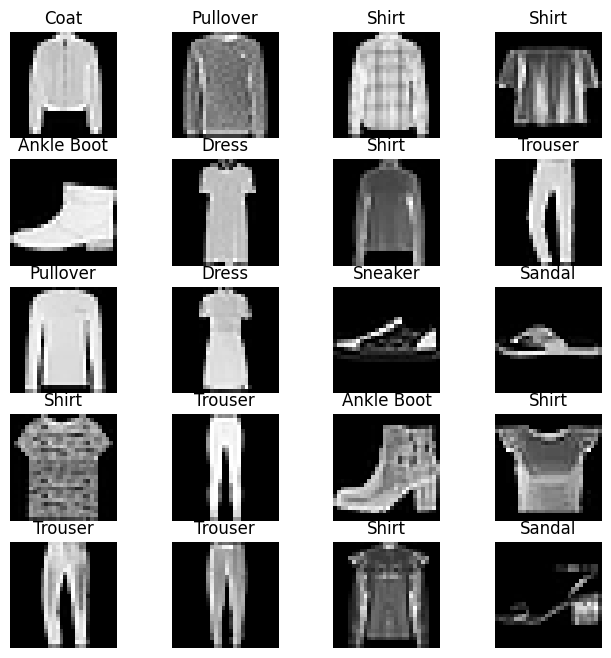

In [9]:
label_map={0: 'T-Shirt',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',5:'Sandal',6:'Shirt',7:'Sneaker',8:'Bag',9:'Ankle Boot'}

fig=plt.figure(figsize=(8,8)); #;이거 안붙여도 되는듯
columns=4;
rows=5;
for i in range(1,columns*rows+1):
  img_xy=np.random.randint(len(train_dataset))
  img=train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows,columns,i)
  plt.title(label_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img,cmap='gray')
plt.show()


`train_dataset[img_xy][0][0,:,:]` 해석

- `train_dataset[img_xy]`
  → `img_xy`번째 데이터 샘플 선택  
  → 보통 `(image, label)` 형태

- `train_dataset[img_xy][0]`
  → 샘플의 첫 번째 요소인 **image tensor** 선택

- `[0,:,:]`
  → 이미지 tensor의 첫 번째 채널 선택  
  → `:` 는 해당 차원의 전체 범위를 의미

즉,

`[0,:,:] = [첫 번째 채널, 모든 행, 모든 열]`

예를 들어 이미지 shape이 `(1,28,28)`이면:

- `1` : 채널 수
- `28` : 높이
- `28` : 너비

따라서 결과 shape은 `(28,28)`가 되어 실제 이미지 픽셀 값만 추출하게 된다.

합성곱 신경망과 합성곱 신경망이 아닌 심층 신경망의 비교를 위해 먼저 심층 신경망을 생성한 후
학습시켜 보겠습니다. 즉 ConvNet이 적용되지 않은 네트워크를 먼저 만들어 보겠습니다.

In [18]:
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN,self).__init__()
    self.fc1=nn.Linear(in_features=784,out_features=256)
    self.drop=nn.Dropout(0.25)
    self.fc2=nn.Linear(in_features=256,out_features=128)
    self.fc3=nn.Linear(in_features=128,out_features=10)
  def forward(self,input_data):
    out=input_data.view(-1,784)
    out=F.relu(self.fc1(out))
    out=self.drop(out)
    out=F.relu(self.fc2(out))
    out=self.fc3(out)
    return out

 클래스(class) 형태의 모넬은 항상 torch.nn.Module을 상속받습니다. __ ini t __ ()은 객체가 갖
는 속성 값을 초기화하는 역할을 하며 객체가 생성될 때 자동으로 호출됩니다. super( FashionDNN,
self). __ init __ ()은 nn.Module 클래스를 상속받겠다는 의미로 이해하면 됩니다.

 nn은 답러닝 모벨(네트워크) 구성에 펼요한 모률이 모여 있는 패커지이며， Linear는 단순 선형
회귀 모델을만들때 사용합니다. 이때 사용되는파라미터는다음과같습니다.

@ in_ features: 입 력 의 크기 (input size)   
@ out_ features: 출력의 크기output size)


torch.nn.Dropout(p)는 p만큼의 비율로 댄서의 값이 0이 되고， 0이 되지 않는 값들은 기존 값
에 (l/(l-p))만를 곱해져 커집니다. 예를 들어 p=0.3이라는 의미는 전체 값 중 0.3의 확률로 0이
된다는 것이며， 0이 되지 않는 0.7에 해당하는 값은 (1/(1-0.7))만큼 커집니다.


 forward() 함수는 모댈이 학습 데이터를 입력받아서 순전파(for'vvard propagation) 학습을 진행
시키며， **반드시 forward라는 이름의 함수**여야 합니다. 즉 forward( )는 모댈이 학습 데이터를 입
력받아서 순전파 연산을 진행하는 함수이며， 객체를 데이터와 함께 호출하면 **자동으로 실행**됩니
다. 이때 순전파 연산이란H(x) 식에 입력 x로부터 예측된y를 얻는 것입니다.


파이토치에서 사용하는 뷰(viεw)는 넘파이의 reshape과 같은 역할로 댄서의 크기(shap강)를 변
경해 주는 역할을 합니다. 따라서 input_data.view(-1 , 784)는 input_data를 (7, 784)의 크기
로 변경하라는 의미

활성화함수를지정할때는디음두가지 방법이 가능합니다.   
• F . relu (): forward () 함수에서 정의   
• nn. ReLU(): __ ini t __ () 함수에서 정의   

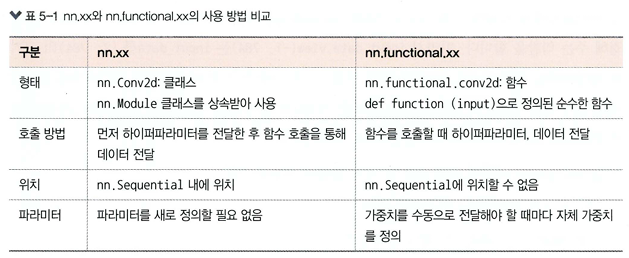

In [19]:
learning_rate=0.001;
model=FashionDNN();
model.to(device)
criterion=nn.CrossEntropyLoss();
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


## 심층신경망

In [20]:
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]
predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)
    train=Variable(images.view(100,1,28,28))
    labels=Variable(labels)
    outputs=model(train)
    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count+=1

    if not (count%50):
      total=0
      correct=0
      for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        labels_list.append(labels)
        test=Variable(images.view(100,1,28,28))
        outputs=model(test)
        predictions=torch.max(outputs,1)[1].to(device)
        predictions_list.append(predictions)
        correct+=(predictions==labels).sum()
        total+=len(labels)

      accuracy=correct*100/total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)
    if not (count%500):
      print('Iteration: {},Loss: {}, Accuracy: {}%'.format(count,loss.data,accuracy))



Iteration: 500,Loss: 0.599704384803772, Accuracy: 83.30999755859375%
Iteration: 1000,Loss: 0.49857616424560547, Accuracy: 84.57999420166016%
Iteration: 1500,Loss: 0.36341407895088196, Accuracy: 85.18000030517578%
Iteration: 2000,Loss: 0.3591238856315613, Accuracy: 85.68000030517578%
Iteration: 2500,Loss: 0.29346564412117004, Accuracy: 85.87999725341797%
Iteration: 3000,Loss: 0.3227420747280121, Accuracy: 86.0199966430664%


## 합성곱 신경망

In [23]:
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN,self).__init__()
    self.layer1=nn.Sequential(
      nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1),#stride가 명시되어 있지 않다면 (1，1)
      nn.BatchNorm2d(32),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2,stride=2)
      )
    self.layer2=nn.Sequential(
      nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3),
      nn.BatchNorm2d(64),
      nn.ReLU(),
      nn.MaxPool2d(2)
      )
    self.fc1=nn.Linear(in_features=64*6*6,out_features=600)
    self.drop=nn.Dropout2d(0.25)
    self.fc2=nn.Linear(in_features=600,out_features=120)
    self.fc3=nn.Linear(in_features=120,out_features=10)

  def forward(self,x):
    out=self.layer1(x)
    out=self.layer2(out)
    out=out.view(out.size(0),-1) # 합성곱층에서 완전연결층으로 변경되기 때문에 데이터의 형태를 1차원으로 바꾸어 줍니다.
    out=self.fc1(out)
    out=self.drop(out)
    out=self.fc2(out)
    out=self.fc3(out)
    return out


 nn.Sequential은 여러 개의 계층을 하나의 컨테이너에 구현하는 방법
이라고 생각하면 됩니다.

nn.Conv2d( in_channels=1 , 0ut channels=32 , kernel size=3, padding=1)



@ in_channels: 입력 채널의 수를 의미합니다. 흑백 이미지는 1. RGB 값을 가진 이미지는
3을 가진 경우가 많습니다.

@out_channels: 출력 채널의 수를 의미합니다.   
@ kernel_size: 커널 크기를 의미  
@padding: 패딩 크기를 의미하는 것으로 출력 크기를 조정하기 위해 입력 데이터 주위에 0을
재읍니다. 패딩 값이 클수록 출력 크기도 커집니다.

 BatchN orm2d는 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균
과 분산을 이용하여 정규화하는 것을 의미

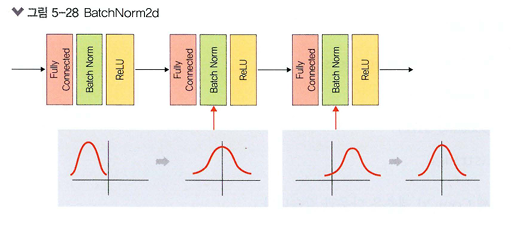

MaxPoo12d는 이미지 크기를 축소시키는 용도로 사용합니다. 풀링 계층은 합성곱층의 출력
데이터를 입력으로 받아서 출력 데이터(따aχcti따ivat따t
하는 용도로 λ사}녕

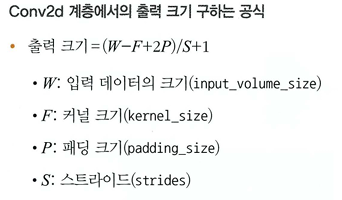

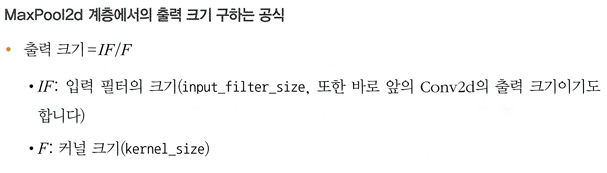

In [26]:
learning_rate=0.001
model=FashionCNN()
model.to(device)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [27]:
num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]
predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)
    train=Variable(images.view(100,1,28,28))
    labels=Variable(labels)
    outputs=model(train)
    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count+=1

    if not (count%50):
      total=0
      correct=0
      for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        labels_list.append(labels)
        test=Variable(images.view(100,1,28,28))
        outputs=model(test)
        predictions=torch.max(outputs,1)[1].to(device)
        predictions_list.append(predictions)
        correct+=(predictions==labels).sum()
        total+=len(labels)

      accuracy=correct*100/total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)
    if not (count%500):
      print('Iteration: {},Loss: {}, Accuracy: {}%'.format(count,loss.data,accuracy))



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500,Loss: 0.4269357919692993, Accuracy: 87.0%
Iteration: 1000,Loss: 0.3992427885532379, Accuracy: 87.88999938964844%
Iteration: 1500,Loss: 0.33935242891311646, Accuracy: 88.00999450683594%
Iteration: 2000,Loss: 0.17461980879306793, Accuracy: 88.50999450683594%
Iteration: 2500,Loss: 0.11574207991361618, Accuracy: 89.31999969482422%
Iteration: 3000,Loss: 0.20067022740840912, Accuracy: 90.07999420166016%
